加载模型数据...
计算改进指标...

性能改进分析摘要

【整体性能指标】
----------------------------------------------------------------------------------------------------
模型                               NSE         RMSE          MAE        KGE
----------------------------------------------------------------------------------------------------
Baseline ANN                  0.9456       179.91        89.72     0.9246
Flood-Focused ANN             0.9492       173.83        87.97     0.9474
Super Ensemble                0.9494       173.59        87.38     0.9479
----------------------------------------------------------------------------------------------------

【洪水期性能指标】
----------------------------------------------------------------------------------------------------
模型                           NSE_flood      RMSE_flood       MAE_flood    KGE_flood
----------------------------------------------------------------------------------------------------
Baseline ANN                    0.8495       496.63 m³/s       3

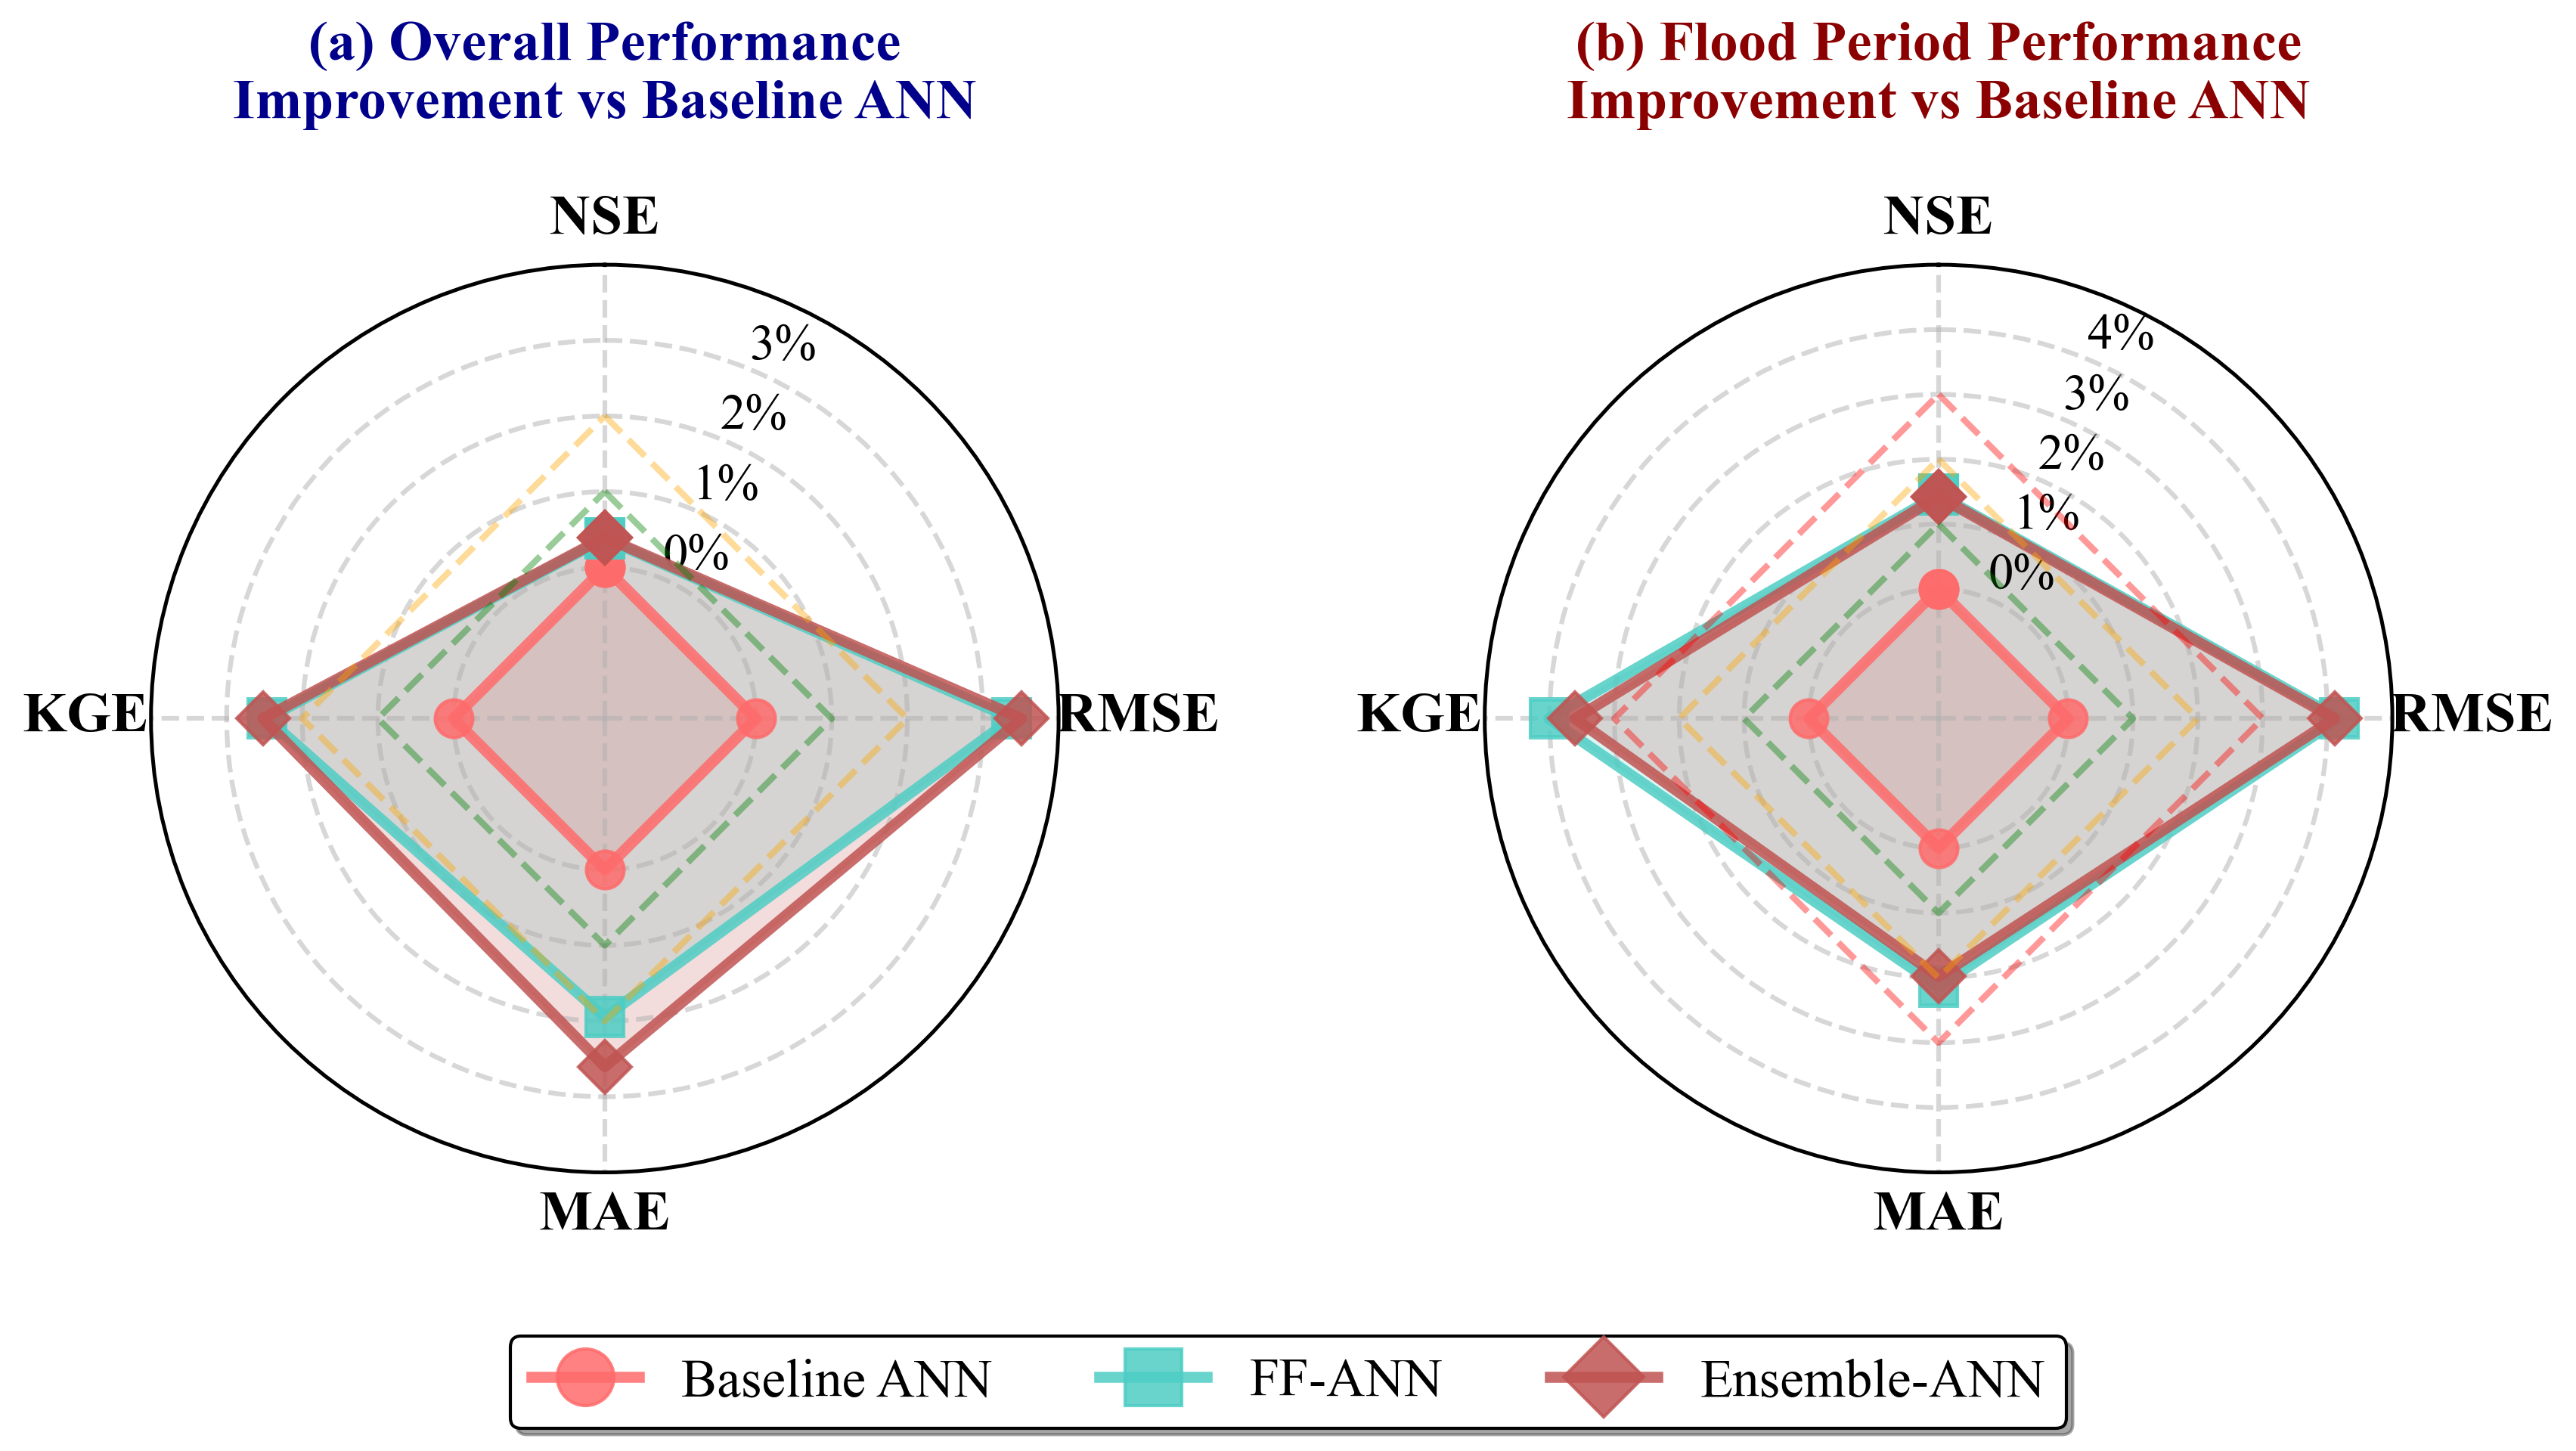


✓ 改进分析完成！


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os

# 设置字体为英文罗马字体
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 14

def load_comparison_models(results_dir='results'):
    """
    加载3个对比模型的预测结果和指标
    """
    # 1. Baseline ANN（无台风特征）
    baseline_pred = pd.read_csv('predictions/baseline_ANN_predictions.csv')
    
    # 2. Flood-Focused ANN
    flood_ann_pred = pd.read_csv('predictions/optimized/flood_focused_ann.csv')
    
    # 3. Super Ensemble
    super_ensemble_pred = pd.read_csv('predictions/optimized/super_ensemble_top3.csv')
    
    # 加载指标
    with open(os.path.join(results_dir, 'baseline_results.json'), 'r') as f:
        baseline_metrics = json.load(f)['ANN']['metrics']
    
    with open(os.path.join(results_dir, 'optimized/final_summary.json'), 'r') as f:
        optimized_data = json.load(f)
        flood_ann_metrics = optimized_data['all_models']['flood_focused_ann']
        super_ensemble_metrics = optimized_data['all_models']['Super_Ensemble']
    
    return {
        'Baseline ANN': {'pred': baseline_pred, 'metrics': baseline_metrics},
        'Flood-Focused ANN': {'pred': flood_ann_pred, 'metrics': flood_ann_metrics},
        'Super Ensemble': {'pred': super_ensemble_pred, 'metrics': super_ensemble_metrics}
    }

def calculate_improvements(models_data):
    """
    计算整体和洪水期的改进指标
    """
    improvements = {}
    
    baseline_metrics = models_data['Baseline ANN']['metrics']
    
    for model_name, data in models_data.items():
        metrics = data['metrics']
        
        # 相对于Baseline的改进百分比
        if model_name == 'Baseline ANN':
            overall_nse_imp = 0
            overall_rmse_imp = 0
            overall_mae_imp = 0
            overall_kge_imp = 0
            
            flood_nse_imp = 0
            flood_rmse_imp = 0
            flood_mae_imp = 0
            flood_kge_imp = 0
        else:
            # 整体改进
            overall_nse_imp = ((metrics['NSE'] - baseline_metrics['NSE']) / 
                              abs(baseline_metrics['NSE'])) * 100
            overall_rmse_imp = ((baseline_metrics['RMSE'] - metrics['RMSE']) / 
                               baseline_metrics['RMSE']) * 100
            overall_mae_imp = ((baseline_metrics['MAE'] - metrics['MAE']) / 
                              baseline_metrics['MAE']) * 100
            overall_kge_imp = ((metrics['KGE'] - baseline_metrics['KGE']) / 
                              abs(baseline_metrics['KGE'])) * 100
            
            # 洪水期改进
            flood_nse_imp = ((metrics['NSE_flood'] - baseline_metrics['NSE_flood']) / 
                            abs(baseline_metrics['NSE_flood'])) * 100
            flood_rmse_imp = ((baseline_metrics['RMSE_flood'] - metrics['RMSE_flood']) / 
                             baseline_metrics['RMSE_flood']) * 100
            flood_mae_imp = ((baseline_metrics['MAE_flood'] - metrics['MAE_flood']) / 
                            baseline_metrics['MAE_flood']) * 100
            flood_kge_imp = ((metrics['KGE_flood'] - baseline_metrics['KGE_flood']) / 
                            abs(baseline_metrics['KGE_flood'])) * 100
        
        improvements[model_name] = {
            # 绝对值
            'NSE': metrics['NSE'],
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'KGE': metrics['KGE'],
            'NSE_flood': metrics['NSE_flood'],
            'RMSE_flood': metrics['RMSE_flood'],
            'MAE_flood': metrics['MAE_flood'],
            'KGE_flood': metrics['KGE_flood'],
            
            # 改进百分比
            'overall_nse_imp': overall_nse_imp,
            'overall_rmse_imp': overall_rmse_imp,
            'overall_mae_imp': overall_mae_imp,
            'overall_kge_imp': overall_kge_imp,
            'flood_nse_imp': flood_nse_imp,
            'flood_rmse_imp': flood_rmse_imp,
            'flood_mae_imp': flood_mae_imp,
            'flood_kge_imp': flood_kge_imp
        }
    
    return improvements

def plot_radar_improvements(improvements,
                           output_file='results/Figure5_radar_improvements.png',
                           figsize=(12, 6), dpi=300):
    """
    绘制雷达图：左侧整体性能，右侧洪水期性能
    """
    model_names = ['Baseline ANN', 'Flood-Focused ANN', 'Super Ensemble']
    colors = ['#ff6b6b', '#4ecdc4', '#c05452']  # 红色（基准）、青色、蓝色
    markers = ['o', 's', 'D']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=dpi,
                                   subplot_kw=dict(projection='polar'))
    
    # ==================== (a) 整体性能雷达图 ====================
    categories_overall = ['NSE', 'RMSE', 'MAE', 'KGE']
    num_vars = len(categories_overall)
    
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]
    
    ax1.set_theta_offset(np.pi / 2)
    ax1.set_theta_direction(-1)
    
    for i, model_name in enumerate(model_names):
        imp = improvements[model_name]
        
        # 整体性能改进（相对于Baseline，百分比）
        values = [
            imp['overall_nse_imp'],
            imp['overall_rmse_imp'],
            imp['overall_mae_imp'],
            imp['overall_kge_imp']
        ]
        values += values[:1]
        
        # 绘制雷达图
        ax1.plot(angles, values, marker=markers[i], linewidth=3.5, 
                label=model_name, color=colors[i], markersize=12, alpha=0.85)
        ax1.fill(angles, values, alpha=0.2, color=colors[i])
        
   
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(['NSE', '     RMSE', 'MAE', 'KGE   '], fontsize=18, fontweight='bold')
    ax1.set_ylim(-2, 4)
    ax1.set_yticks([0, 1, 2, 3])
    ax1.set_yticklabels(['0%', '1%', '2%', '3%'], fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.5, linewidth=1.5)
    ax1.set_title('(a) Overall Performance\nImprovement vs Baseline ANN', 
                 fontsize=18, fontweight='bold', pad=25, color='darkblue')
    
    # 添加参考圆（1%, 2%）
    ax1.plot(angles, [1.0]*len(angles), 'g--', linewidth=2, alpha=0.4, label='1% Improvement')
    ax1.plot(angles, [2.0]*len(angles), 'orange', linestyle='--', linewidth=2, alpha=0.4, label='2% Improvement')
    
    # ==================== (b) 洪水期性能雷达图 ====================
    categories_flood = ['NSE', 'RMSE', 'MAE', 'KGE']
    
    ax2.set_theta_offset(np.pi / 2)
    ax2.set_theta_direction(-1)
    
    for i, model_name in enumerate(model_names):
        imp = improvements[model_name]
        
        # 洪水期性能改进
        values = [
            imp['flood_nse_imp'],
            imp['flood_rmse_imp'],
            imp['flood_mae_imp'],
            imp['flood_kge_imp']
        ]
        values += values[:1]
        
        # 绘制雷达图
        ax2.plot(angles, values, marker=markers[i], linewidth=3.5,
                label=model_name, color=colors[i], markersize=12, alpha=0.85)
        ax2.fill(angles, values, alpha=0.2, color=colors[i])
        
    
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(['NSE', '     RMSE', 'MAE', 'KGE   '], fontsize=18, fontweight='bold')
    ax2.set_ylim(-2, 5)
    ax2.set_yticks([0, 1, 2, 3, 4])
    ax2.set_yticklabels(['0%', '1%', '2%', '3%', '4%'], fontsize=16)
    ax2.grid(True, linestyle='--', alpha=0.5, linewidth=1.5)
    ax2.set_title('(b) Flood Period Performance\nImprovement vs Baseline ANN', 
                 fontsize=18, fontweight='bold', pad=25, color='darkred')
    
    # 添加参考圆
    ax2.plot(angles, [1.0]*len(angles), 'g--', linewidth=2, alpha=0.4)
    ax2.plot(angles, [2.0]*len(angles), 'orange', linestyle='--', linewidth=2, alpha=0.4)
    ax2.plot(angles, [3.0]*len(angles), 'red', linestyle='--', linewidth=2, alpha=0.4)
    
    # 添加统一图例
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles[:3], ['Baseline ANN', 'FF-ANN', 'Ensemble-ANN'], loc='lower center', 
              bbox_to_anchor=(0.5, -0.1),
              ncol=3, fontsize=17, frameon=True, 
              edgecolor='black', fancybox=True, shadow=True,
              markerscale=1.5)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    
    # 保存图像
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', pad_inches=0.3)
    print(f"✓ Radar improvement chart saved to: {output_file}")
    
    plt.show()

def print_improvement_summary(improvements):
    """
    打印改进效果摘要
    """
    print("\n" + "="*100)
    print("性能改进分析摘要")
    print("="*100)
    
    print("\n【整体性能指标】")
    print("-"*100)
    print(f"{'模型':<25} {'NSE':>10} {'RMSE':>12} {'MAE':>12} {'KGE':>10}")
    print("-"*100)
    for model_name, imp in improvements.items():
        print(f"{model_name:<25} {imp['NSE']:>10.4f} {imp['RMSE']:>12.2f} {imp['MAE']:>12.2f} {imp['KGE']:>10.4f}")
    print("-"*100)
    
    print("\n【洪水期性能指标】")
    print("-"*100)
    print(f"{'模型':<25} {'NSE_flood':>12} {'RMSE_flood':>15} {'MAE_flood':>15} {'KGE_flood':>12}")
    print("-"*100)
    for model_name, imp in improvements.items():
        print(f"{model_name:<25} {imp['NSE_flood']:>12.4f} {imp['RMSE_flood']:>12.2f} m³/s {imp['MAE_flood']:>12.2f} m³/s {imp['KGE_flood']:>12.4f}")
    print("-"*100)
    
    print("\n【相对于Baseline ANN的改进百分比】")
    print("-"*100)
    print(f"{'模型':<25} {'指标类别':<15} {'NSE改进':>12} {'RMSE降低':>12} {'MAE降低':>12} {'KGE改进':>12}")
    print("-"*100)
    
    for model_name in ['Flood-Focused ANN', 'Super Ensemble']:
        if model_name in improvements:
            imp = improvements[model_name]
            
            # 整体性能
            print(f"{model_name:<25} {'Overall':<15} {imp['overall_nse_imp']:>11.2f}% {imp['overall_rmse_imp']:>11.2f}% {imp['overall_mae_imp']:>11.2f}% {imp['overall_kge_imp']:>11.2f}%")
            
            # 洪水期性能
            print(f"{'':<25} {'Flood Period':<15} {imp['flood_nse_imp']:>11.2f}% {imp['flood_rmse_imp']:>11.2f}% {imp['flood_mae_imp']:>11.2f}% {imp['flood_kge_imp']:>11.2f}%")
            print("-"*100)
    
    # 关键发现
    print("\n🏆 关键发现:")
    
    if 'Flood-Focused ANN' in improvements:
        flood_ann = improvements['Flood-Focused ANN']
        print(f"\n  💡 Flood-Focused ANN 相对于 Baseline ANN:")
        print(f"     整体性能:")
        print(f"       • NSE提升: {flood_ann['overall_nse_imp']:+.2f}%")
        print(f"       • RMSE降低: {flood_ann['overall_rmse_imp']:+.2f}%")
        print(f"     洪水期性能:")
        print(f"       • NSE提升: {flood_ann['flood_nse_imp']:+.2f}% ⭐")
        print(f"       • RMSE降低: {flood_ann['flood_rmse_imp']:+.2f}%")
    
    if 'Super Ensemble' in improvements:
        ensemble = improvements['Super Ensemble']
        print(f"\n  💡 Super Ensemble 相对于 Baseline ANN:")
        print(f"     整体性能:")
        print(f"       • NSE提升: {ensemble['overall_nse_imp']:+.2f}%")
        print(f"       • RMSE降低: {ensemble['overall_rmse_imp']:+.2f}%")
        print(f"     洪水期性能:")
        print(f"       • NSE提升: {ensemble['flood_nse_imp']:+.2f}%")
        print(f"       • RMSE降低: {ensemble['flood_rmse_imp']:+.2f}%")
    
    # 对比洪水期和整体的改进差异
    print(f"\n  📊 洪水期 vs 整体改进对比:")
    for model_name in ['Flood-Focused ANN', 'Super Ensemble']:
        if model_name in improvements:
            imp = improvements[model_name]
            nse_diff = imp['flood_nse_imp'] - imp['overall_nse_imp']
            print(f"     {model_name}: 洪水期NSE额外提升 {nse_diff:+.2f}% (相对于整体改进)")

if __name__ == "__main__":
    print("加载模型数据...")
    models_data = load_comparison_models()
    
    print("计算改进指标...")
    improvements = calculate_improvements(models_data)
    
    # 打印摘要
    print_improvement_summary(improvements)
    
    # 绘制雷达图
    print("\n生成改进效果雷达图...")
    plot_radar_improvements(improvements)
    
    print("\n✓ 改进分析完成！")

洪水事件预测对比分析

正在加载模型预测数据...
✓ 加载: LR (Baseline)
✓ 加载: ANN (Baseline)
✓ 加载: RF (Baseline)
✓ 加载: XGB (Baseline)
✓ 加载: FF-ANN (Flood-Focused ANN)
✓ 加载: Ensemble-ANN (Super Ensemble)

成功加载 6 个模型的预测数据

正在绘制最大2次洪水事件时序对比图...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_36804\692581754.py:403: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.97])


✓ 图表已保存至: results/Figure6_flood_comparison.png


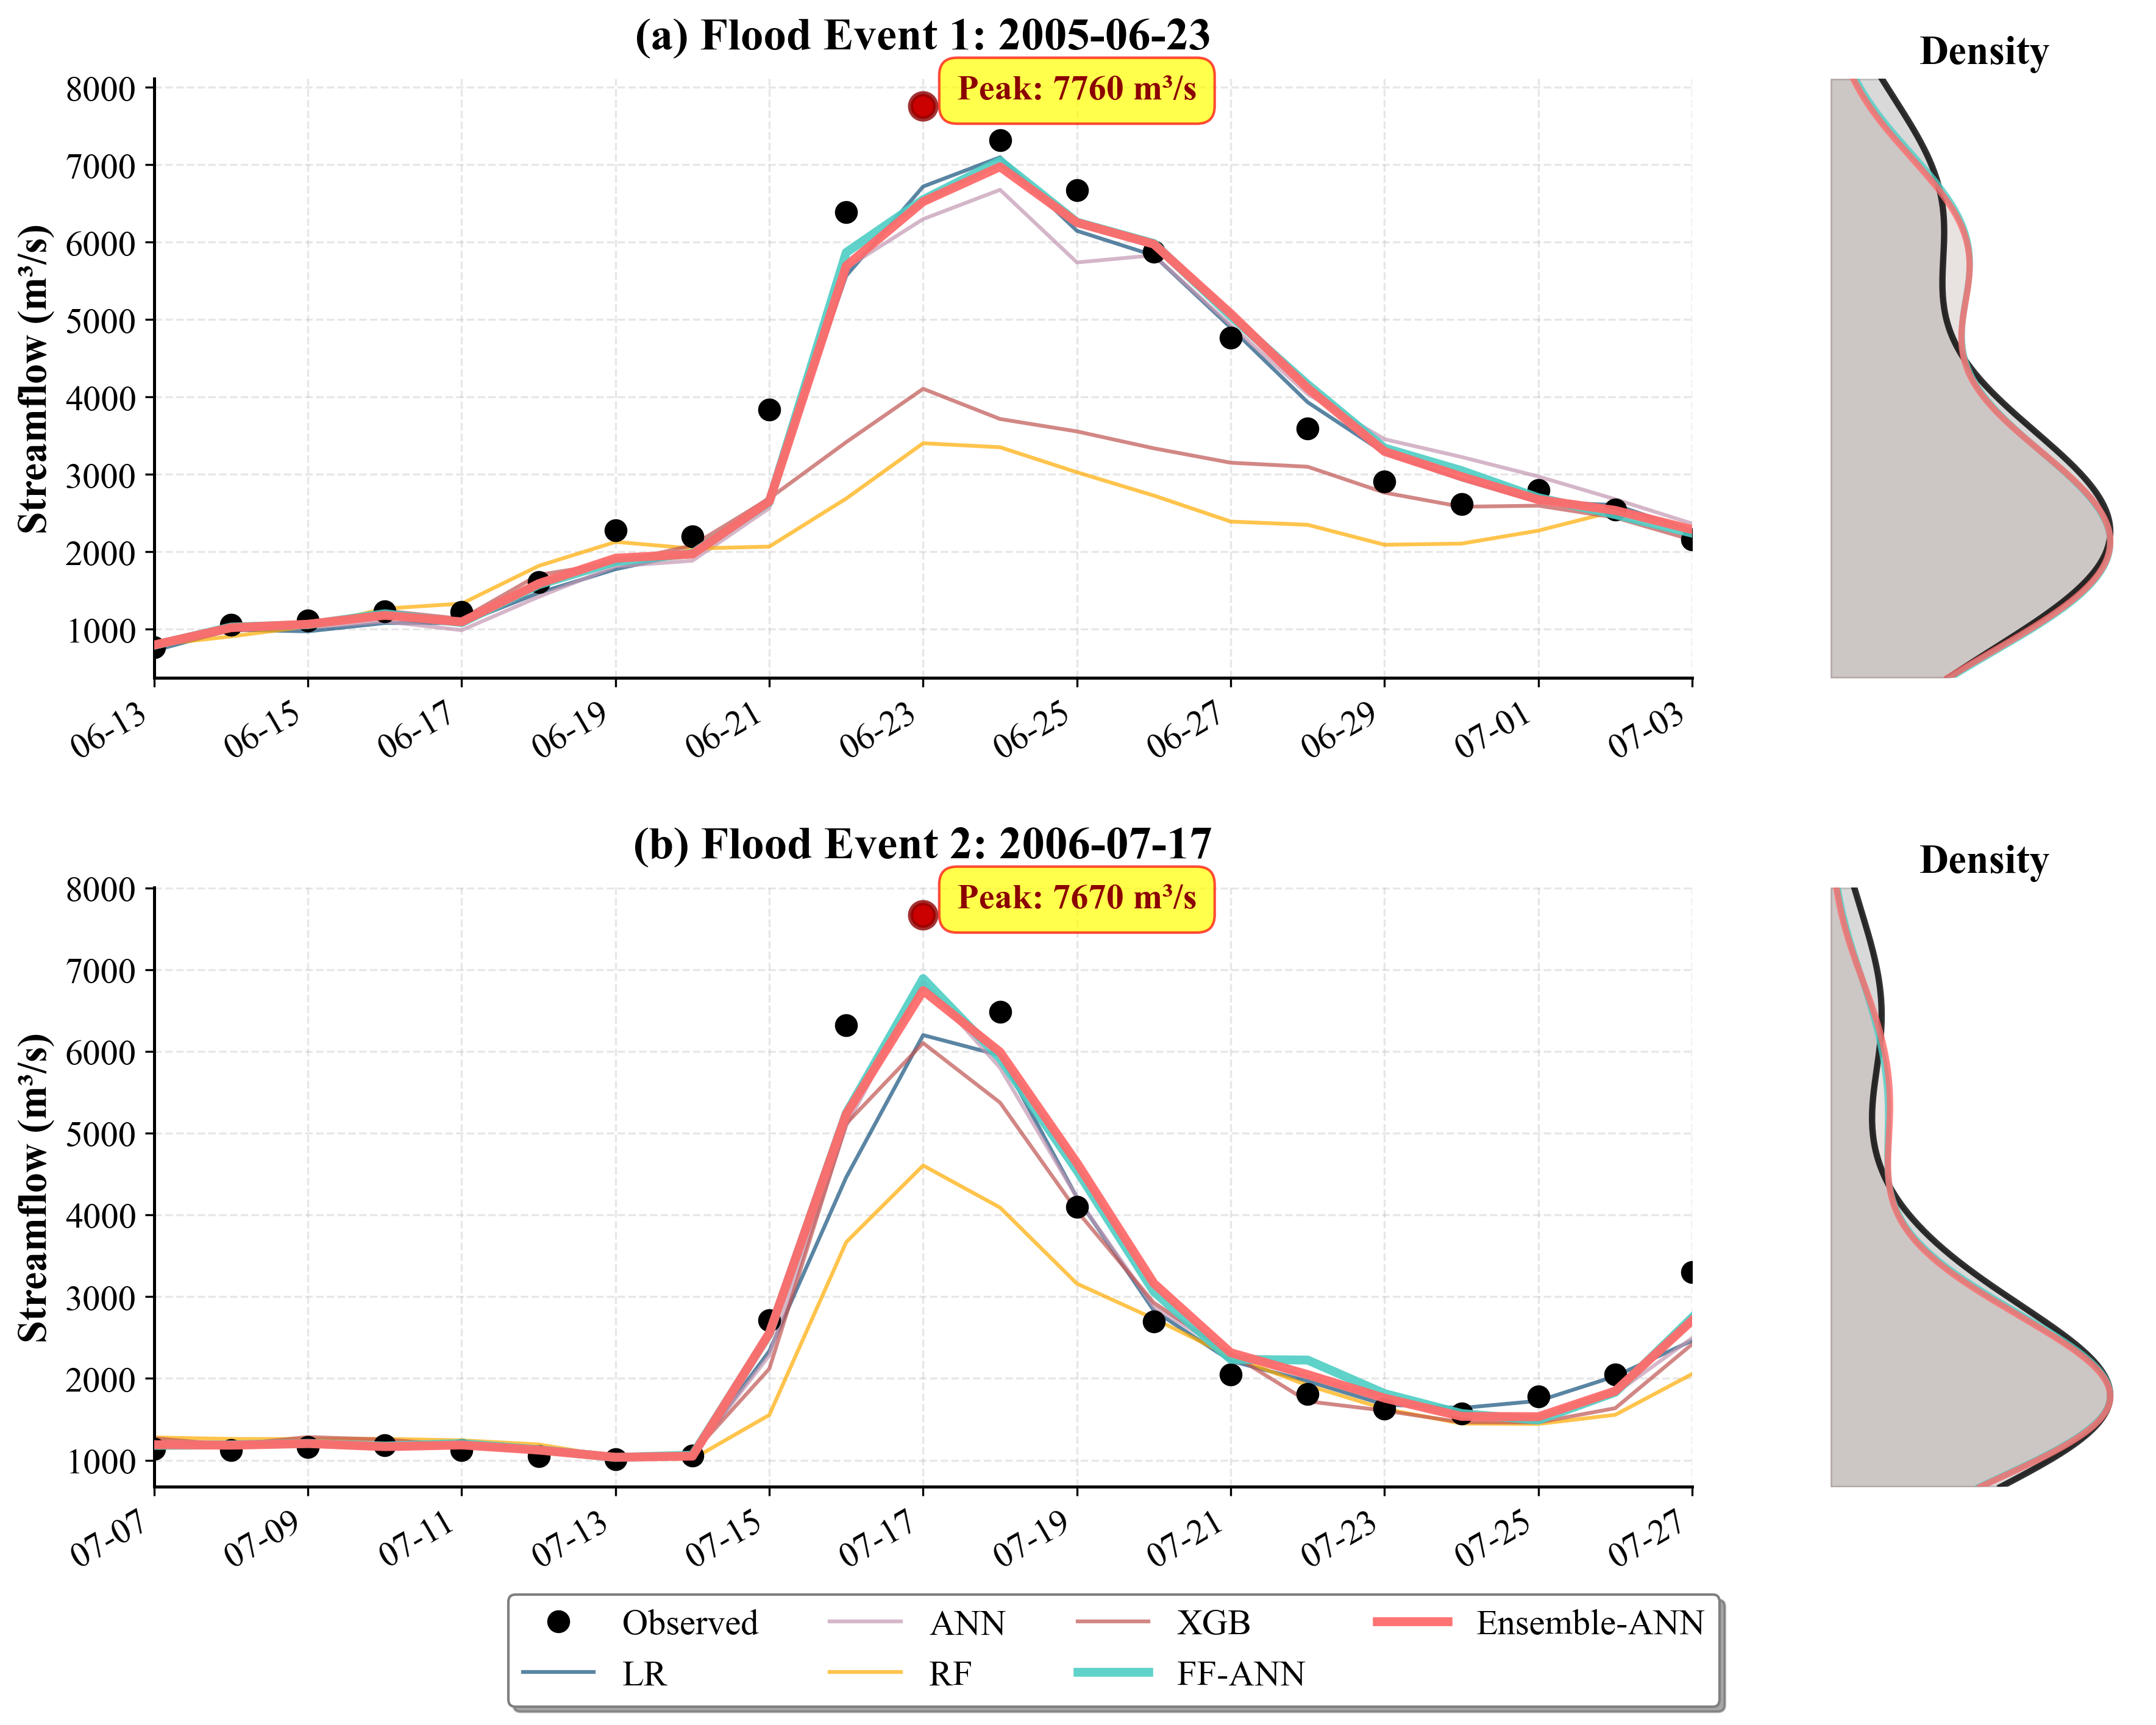


✓ 程序执行完成！结果保存于: results/Figure6_flood_comparison.png


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from datetime import datetime, timedelta
from matplotlib.dates import AutoDateLocator, DateFormatter
from scipy.stats import gaussian_kde

# -------------------------- 基础配置 --------------------------
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["lines.linewidth"] = 2.0
plt.rcParams["lines.markersize"] = 6

# 模型颜色配置（区分基础模型和优化模型）
MODEL_STYLE = {
    "color": {
        "Observed": "black",
        "LR": "#14517c",           # 蓝色（基础模型）
        "ANN": "#c497b2",          # 绿色（基础模型）
        "RF": "#ffab00",           # 橙色（基础模型）
        "XGB": "#c05452",          # 红棕色（基础模型）
        "FF-ANN": "#4ecdc4",       # 青色（优化模型）⭐
        "Ensemble-ANN": "#ff6b6b"  # 红色（最优模型）⭐⭐
    },
    "line_style": {
        "Observed": "",
        "LR": "-",
        "ANN": "-",
        "RF": "-",
        "XGB": "-",
        "FF-ANN": "-",
        "Ensemble-ANN": "-"
    },
    "marker": {
        "Observed": "o",
        "LR": "s",
        "ANN": "s",
        "RF": "s",
        "XGB": "s",
        "FF-ANN": "p",
        "Ensemble-ANN": "p"
    },
    "alpha": {
        "LR": 0.7,
        "ANN": 0.7,
        "RF": 0.7,
        "XGB": 0.7,
        "FF-ANN": 0.9,
        "Ensemble-ANN": 0.95
    },
    "linewidth": {
        "Observed": 0,
        "LR": 1.5,
        "ANN": 1.5,
        "RF": 1.5,
        "XGB": 1.5,
        "FF-ANN": 3.5,
        "Ensemble-ANN": 3.5
    }
}

# -------------------------- 数据处理函数 --------------------------
def find_top_flood_events(observed_data, window_size=7, top_n=2):
    """
    识别观测数据中流量最大的前N次洪水事件
    """
    required_columns = ['date', 'observed']
    if not all(col in observed_data.columns for col in required_columns):
        missing = [col for col in required_columns if col not in observed_data.columns]
        raise ValueError(f"观测数据缺少必要列: {missing}")
    
    observed_data = observed_data.copy()
    observed_data['date'] = pd.to_datetime(observed_data['date'])
    observed_data = observed_data.sort_values('date').reset_index(drop=True)
    
    # 识别洪峰
    observed_data['is_peak'] = observed_data['observed'] > observed_data['observed'].shift(1)
    observed_data['is_peak'] &= observed_data['observed'] > observed_data['observed'].shift(-1)
    peaks = observed_data[observed_data['is_peak']].sort_values('observed', ascending=False)
    
    if len(peaks) < top_n:
        peak_indices = observed_data['observed'].nlargest(top_n).index
        peaks = observed_data.loc[peak_indices].sort_values('observed', ascending=False)
    
    flood_events = []
    used_dates = set()
    
    for _, peak in peaks.iterrows():
        if len(flood_events) >= top_n:
            break
            
        peak_date = peak['date']
        peak_value = peak['observed']
        
        start_date = peak_date - timedelta(days=window_size//2)
        end_date = peak_date + timedelta(days=window_size - window_size//2)
        
        overlap = False
        for d in pd.date_range(start_date, end_date):
            if d in used_dates:
                overlap = True
                break
                
        if overlap:
            continue
            
        for d in pd.date_range(start_date, end_date):
            used_dates.add(d)
            
        flood_event = observed_data[
            (observed_data['date'] >= start_date) & 
            (observed_data['date'] <= end_date)
        ].copy()
        
        flood_events.append({
            'data': flood_event,
            'start_date': start_date,
            'end_date': end_date,
            'peak_date': peak_date,
            'peak_value': peak_value
        })
    
    return flood_events

def load_comparison_predictions():
    """
    加载对比模型的预测结果：
    - 4个基础模型（无台风特征）
    - Flood-Focused ANN (FF-ANN)
    - Super Ensemble (Ensemble-ANN)
    """
    predictions = {}
    
    # 1. 加载基础模型（无台风特征）
    baseline_models = ['LR', 'ANN', 'RF', 'XGB']
    for model in baseline_models:
        file_path = f'predictions/baseline_{model}_predictions.csv'
        if os.path.exists(file_path):
            pred_df = pd.read_csv(file_path)
            pred_df['date'] = pd.to_datetime(pred_df['date'])
            predictions[model] = pred_df
            print(f"✓ 加载: {model} (Baseline)")
        else:
            print(f"✗ 未找到: {file_path}")
    
    # 2. 加载Flood-Focused ANN (重命名为FF-ANN)
    flood_ann_path = 'predictions/optimized/flood_focused_ann.csv'
    if os.path.exists(flood_ann_path):
        pred_df = pd.read_csv(flood_ann_path)
        pred_df['date'] = pd.to_datetime(pred_df['date'])
        predictions['FF-ANN'] = pred_df  # 使用新名称
        print(f"✓ 加载: FF-ANN (Flood-Focused ANN)")
    else:
        print(f"✗ 未找到: {flood_ann_path}")
    
    # 3. 加载Super Ensemble (重命名为Ensemble-ANN)
    ensemble_path = 'predictions/optimized/super_ensemble_top3.csv'
    if os.path.exists(ensemble_path):
        pred_df = pd.read_csv(ensemble_path)
        pred_df['date'] = pd.to_datetime(pred_df['date'])
        predictions['Ensemble-ANN'] = pred_df  # 使用新名称
        print(f"✓ 加载: Ensemble-ANN (Super Ensemble)")
    else:
        print(f"✗ 未找到: {ensemble_path}")
    
    if not predictions:
        raise ValueError("未找到任何有效预测文件")
    
    return predictions

# -------------------------- 绘图函数 --------------------------
def plot_flood_comparison(
    predictions, 
    output_file='results/Figure6_flood_comparison.png',
    figsize=(14, 10), 
    dpi=300, 
    window_size=20, 
    top_n=2
):
    """
    绘制2次最大洪水事件对比图：基础模型 vs 优化模型
    """
    # 获取观测数据
    first_model = next(iter(predictions.keys()))
    observed_data = predictions[first_model][['date', 'observed']].copy()
    
    # 找到最大的2次洪水事件
    flood_events = find_top_flood_events(observed_data, window_size, top_n)
    if len(flood_events) < top_n:
        print(f"警告: 仅找到 {len(flood_events)} 个不重叠的洪水事件")
        top_n = len(flood_events)
    
    # 创建2行2列布局（左侧时序图+右侧密度图）
    fig, axes = plt.subplots(
        nrows=top_n, 
        ncols=2, 
        figsize=figsize, 
        dpi=dpi,
        gridspec_kw={'width_ratios': [5, 1], 'hspace': 0.35, 'wspace': 0.15}
    )
    
    # 定义绘制顺序（先画基础模型作为背景，再画优化模型）
    baseline_models = ['LR', 'ANN', 'RF', 'XGB']
    optimized_models = ['FF-ANN', 'Ensemble-ANN']  # 使用新名称
    
    # 为每个洪水事件绘制子图
    for i in range(top_n):
        flood_event = flood_events[i]
        main_ax = axes[i, 0]  # 左侧时序图
        density_ax = axes[i, 1]  # 右侧密度图
        
        event_data = flood_event['data']
        start_date = flood_event['start_date']
        end_date = flood_event['end_date']
        peak_date = flood_event['peak_date']
        peak_value = flood_event['peak_value']
        
        # ==================== 绘制时序图 ====================
        
        # 1. 先绘制基础模型（彩色实线，作为背景）
        for model_name in baseline_models:
            if model_name not in predictions:
                continue
                
            model_data = predictions[model_name]
            model_event_data = model_data[
                (model_data['date'] >= start_date) & 
                (model_data['date'] <= end_date)
            ]
            
            main_ax.plot(
                model_event_data['date'], model_event_data['predicted'],
                color=MODEL_STYLE["color"][model_name],
                linestyle=MODEL_STYLE["line_style"][model_name],
                linewidth=MODEL_STYLE["linewidth"][model_name],
                alpha=MODEL_STYLE["alpha"][model_name],
                label=f'{model_name}' if i == 0 else "",  # 移除(Baseline)后缀
                zorder=2
            )
        
        # 2. 绘制观测数据（黑色点，中等层）
        main_ax.plot(
            event_data['date'], event_data['observed'],
            color=MODEL_STYLE["color"]["Observed"],
            marker=MODEL_STYLE["marker"]["Observed"],
            linestyle="",
            markersize=8,
            label="Observed" if i == 0 else "",
            zorder=5
        )
        
        # 3. 绘制优化模型（更粗的彩色线，突出显示，最上层）
        for model_name in optimized_models:
            if model_name not in predictions:
                continue
                
            model_data = predictions[model_name]
            model_event_data = model_data[
                (model_data['date'] >= start_date) & 
                (model_data['date'] <= end_date)
            ]
            
            main_ax.plot(
                model_event_data['date'], model_event_data['predicted'],
                color=MODEL_STYLE["color"][model_name],
                linestyle=MODEL_STYLE["line_style"][model_name],
                linewidth=MODEL_STYLE["linewidth"][model_name],
                alpha=MODEL_STYLE["alpha"][model_name],
                label=model_name if i == 0 else "",  # 直接使用新名称
                zorder=10
            )
        
        # 4. 标记洪峰点
        main_ax.scatter(
            peak_date, peak_value,
            color='red', s=100, zorder=15, alpha=0.8,
            edgecolors='darkred', linewidths=2
        )
        main_ax.text(
            peak_date + timedelta(days=2), peak_value,
            f'Peak: {peak_value:.0f} m³/s',
            color='darkred', fontsize=14, fontweight='bold',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7, edgecolor='red'),
            zorder=20
        )
        
        # 5. 美化时序图
        main_ax.set_title(
            f'({chr(97 + i)}) Flood Event {i+1}: {peak_date.strftime("%Y-%m-%d")}',
            fontsize=18, fontweight='bold', pad=12
        )
        main_ax.set_ylabel('Streamflow (m³/s)', fontsize=16, fontweight='bold')
        main_ax.set_xlim(start_date, end_date)
        
        # 日期格式化
        main_ax.xaxis.set_major_locator(AutoDateLocator())
        main_ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))
        plt.setp(main_ax.get_xticklabels(), rotation=30, ha='right')
        
        main_ax.spines['top'].set_visible(False)
        main_ax.spines['right'].set_visible(False)
        main_ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.8, zorder=0)
        main_ax.set_axisbelow(True)
        
        # ==================== 绘制密度图 ====================
        
        # 收集所有数据
        all_series = []
        series_colors = []
        series_linewidths = []
        
        # 1. 添加观测数据
        all_series.append(event_data['observed'].values)
        series_colors.append(MODEL_STYLE["color"]["Observed"])
        series_linewidths.append(2.5)
        
        # 2. 添加优化模型数据
        # 确保使用正确的模型名称
        for model_name in optimized_models:  # ['FF-ANN', 'Ensemble-ANN']
            if model_name in predictions:
                model_data = predictions[model_name]
                model_event_data = model_data[
                    (model_data['date'] >= start_date) & 
                    (model_data['date'] <= end_date)
                ]
                all_series.append(model_event_data['predicted'].values)
                series_colors.append(MODEL_STYLE["color"][model_name])
                series_linewidths.append(2.5)
        
        # 确定y轴范围
        if len(all_series) > 0:
            y_min = min(np.min(series) for series in all_series)
            y_max = max(np.max(series) for series in all_series)
            y_range = y_max - y_min
            y_margin = y_range * 0.1
            y_plot_range = np.linspace(y_min - y_margin, y_max + y_margin, 200)
            
            # 绘制密度曲线
            for series, color, lw in zip(all_series, series_colors, series_linewidths):
                if len(series) > 1:  # 确保有足够的数据点
                    kde = gaussian_kde(series)
                    density = kde(y_plot_range)
                    density_ax.plot(
                        density / density.max(),
                        y_plot_range,
                        color=color,
                        linewidth=lw,
                        alpha=0.8
                    )
                    density_ax.fill_betweenx(
                        y_plot_range, 0, density / density.max(),
                        color=color, alpha=0.15
                    )
            
            # 美化密度图
            density_ax.set_ylim(y_min - y_margin, y_max + y_margin)
            density_ax.set_xlim(0, 1.1)
        
        density_ax.set_title('Density', fontsize=16, fontweight='bold')
        density_ax.set_xticks([])
        density_ax.set_yticks([])
        density_ax.spines['top'].set_visible(False)
        density_ax.spines['left'].set_visible(False)
        density_ax.spines['right'].set_visible(False)
        density_ax.spines['bottom'].set_visible(False)
    
    # 添加统一图例
    handles, labels = axes[0, 0].get_legend_handles_labels()
    
    # 整理图例顺序：Observed, 基础模型, 优化模型
    legend_order = ['Observed'] + baseline_models + optimized_models
    ordered_handles = []
    ordered_labels = []
    
    for label in legend_order:
        if label in labels:
            idx = labels.index(label)
            ordered_handles.append(handles[idx])
            ordered_labels.append(label)
    
    fig.legend(
        ordered_handles, ordered_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        frameon=True,
        edgecolor='gray',
        fancybox=True,
        shadow=True,
        fontsize=14
    )
    
    # 调整布局并保存
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"✓ 图表已保存至: {output_file}")
    
    plt.show()
    return output_file

# -------------------------- 主函数 --------------------------
def main():
    try:
        print("="*80)
        print("洪水事件预测对比分析")
        print("="*80)
        
        print("\n正在加载模型预测数据...")
        model_predictions = load_comparison_predictions()
        print(f"\n成功加载 {len(model_predictions)} 个模型的预测数据")
        
        print("\n正在绘制最大2次洪水事件时序对比图...")
        save_path = plot_flood_comparison(
            model_predictions,
            window_size=20,  # 每个洪水事件展示20天数据
            top_n=2,         # 只展示2次最大洪水
            dpi=300
        )
        
        print("\n" + "="*80)
        print(f"✓ 程序执行完成！结果保存于: {save_path}")
        print("="*80)
        
    except Exception as e:
        print(f"\n✗ 执行出错: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()